In [10]:
!%pip install geopandas
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import zipfile
import requests
import tempfile
import os
import numpy as np
import requests
from io import BytesIO
import numpy as np
import matplotlib.pyplot as plt
import random
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import random
import seaborn as sns
from scipy import stats
import networkit as nk
import powerlaw
from scipy.stats import ks_2samp
from scipy.stats import poisson
import matplotlib.lines as mlines
from shapely.geometry import LineString
from pyproj import CRS, Transformer
import contextily as ctx
import heapq

'%pip' is not recognized as an internal or external command,
operable program or batch file.


P9.2 Determine numerically (looking for the eigenvector) values of ergodic density for the random walk on selected network. [1P]

Node | Numerical     | Analytical    | |Δ|
--------------------------------------------
   0 | 0.09090909 | 0.09090909 | 5.55e-17
   1 | 0.06277056 | 0.06277056 | 0.00e+00
   2 | 0.07142857 | 0.07142857 | 6.94e-17
   3 | 0.03896104 | 0.03896104 | 1.39e-17
   4 | 0.01731602 | 0.01731602 | 0.00e+00
   5 | 0.03030303 | 0.03030303 | 3.12e-17
   6 | 0.02813853 | 0.02813853 | 3.12e-17
   7 | 0.02813853 | 0.02813853 | 2.08e-17
   8 | 0.03679654 | 0.03679654 | 2.78e-17
   9 | 0.00649351 | 0.00649351 | 2.60e-18
  10 | 0.01731602 | 0.01731602 | 6.94e-18
  11 | 0.00649351 | 0.00649351 | 7.81e-18
  12 | 0.00865801 | 0.00865801 | 1.73e-18
  13 | 0.03679654 | 0.03679654 | 6.94e-18
  14 | 0.01082251 | 0.01082251 | 0.00e+00
  15 | 0.01515152 | 0.01515152 | 3.82e-17
  16 | 0.01298701 | 0.01298701 | 3.12e-17
  17 | 0.00649351 | 0.00649351 | 6.07e-18
  18 | 0.00649351 | 0.00649351 | 2.60e-18
  19 | 0.01082251 | 0.01082251 | 2.08e-17
  20 | 0.00865801 | 0.00865801 | 8.67e-18
  21 | 0.00865801 | 0.00865801

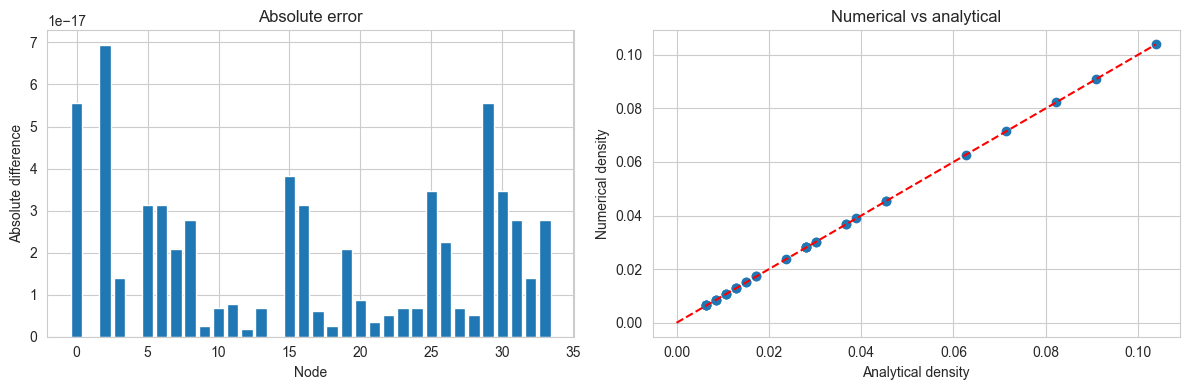

In [11]:
G = nx.karate_club_graph()
A = nx.to_numpy_array(G)
n = A.shape[0]

deg = A.sum(axis=0)

P = A @ np.diag(1 / deg)

vals, vecs = np.linalg.eig(P)
i1 = np.argmin(np.abs(vals - 1))

pi_num = np.abs(vecs[:, i1].real)
pi_num = pi_num / pi_num.sum()

pi_an = deg / deg.sum()

diff = np.abs(pi_num - pi_an)

print("Node | Numerical     | Analytical    | |Δ|")
print("-" * 44)
for i in range(n):
    print(f"{i:>4} | {pi_num[i]:.8f} | {pi_an[i]:.8f} | {diff[i]:.2e}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].bar(range(n), diff)
ax[0].set_xlabel("Node")
ax[0].set_ylabel("Absolute difference")
ax[0].set_title("Absolute error")

ax[1].scatter(pi_an, pi_num)
m = max(pi_an.max(), pi_num.max())
ax[1].plot([0, m], [0, m], 'r--')
ax[1].set_xlabel("Analytical density")
ax[1].set_ylabel("Numerical density")
ax[1].set_title("Numerical vs analytical")

for a in ax:
    a.grid(True)

plt.tight_layout()
plt.show()

P9.3 Determine dynamically (by iterating the Markov operator) ergodic density for the random walk on selected network. [1P]

Node | Dynamic      | Analytical    | |Δ|
--------------------------------------------
   0 | 0.09090910 | 0.09090909 | 7.24e-09
   1 | 0.06277057 | 0.06277056 | 2.94e-09
   2 | 0.07142857 | 0.07142857 | 1.50e-09
   3 | 0.03896104 | 0.03896104 | 2.21e-09
   4 | 0.01731602 | 0.01731602 | 2.55e-09
   5 | 0.03030304 | 0.03030303 | 5.18e-09
   6 | 0.02813853 | 0.02813853 | 4.77e-09
   7 | 0.02813853 | 0.02813853 | 1.46e-09
   8 | 0.03679654 | 0.03679654 | 8.64e-10
   9 | 0.00649351 | 0.00649351 | 2.77e-10
  10 | 0.01731602 | 0.01731602 | 2.71e-09
  11 | 0.00649351 | 0.00649351 | 5.81e-10
  12 | 0.00865801 | 0.00865801 | 6.07e-10
  13 | 0.03679654 | 0.03679654 | 1.23e-09
  14 | 0.01082251 | 0.01082251 | 8.77e-10
  15 | 0.01515151 | 0.01515152 | 1.20e-09
  16 | 0.01298702 | 0.01298701 | 2.48e-09
  17 | 0.00649351 | 0.00649351 | 5.01e-10
  18 | 0.00649351 | 0.00649351 | 5.11e-10
  19 | 0.01082251 | 0.01082251 | 4.51e-10
  20 | 0.00865801 | 0.00865801 | 7.13e-10
  21 | 0.00865801 | 0.00865801 

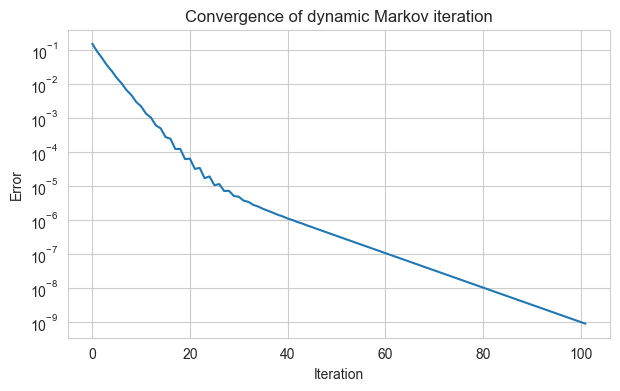

In [12]:
G = nx.karate_club_graph()
A = nx.to_numpy_array(G)
n = A.shape[0]

deg = A.sum(axis=1)

P = A / deg[:, None]

pi = np.random.rand(n)
pi /= pi.sum()

eps = 1e-9
history = []

for _ in range(6000):
    pi_new = pi @ P
    err = np.max(np.abs(pi_new - pi))
    history.append(err)
    pi = pi_new / pi_new.sum()
    if err < eps:
        break

pi_dyn = pi
pi_an = deg / deg.sum()
delta = np.abs(pi_dyn - pi_an)

print("Node | Dynamic      | Analytical    | |Δ|")
print("-" * 44)
for i in range(n):
    print(f"{i:>4} | {pi_dyn[i]:.8f} | {pi_an[i]:.8f} | {delta[i]:.2e}")

plt.figure(figsize=(7, 4))
plt.semilogy(history)
plt.xlabel("Iteration")
plt.ylabel("Error")
plt.title("Convergence of dynamic Markov iteration")
plt.grid(True)
plt.show()

P9.5 Determine the value of classic or modified pagerank for the selected network. [1.5P]

In [13]:
G = nx.karate_club_graph()
N = G.number_of_nodes()

d = 0.85
pr_nx = nx.pagerank(G, alpha=d)

A = nx.to_numpy_array(G)
deg = A.sum(axis=1)

P = np.zeros((N, N))
for i in range(N):
    if deg[i] > 0:
        P[:, i] = A[i] / deg[i]
    else:
        P[:, i] = 1.0 / N

Gmat = d * P + (1 - d) / N * np.ones((N, N))

pi = np.ones(N) / N

tol = 1e-12
for _ in range(10000):
    pi_new = Gmat @ pi
    pi_new /= pi_new.sum()
    if np.linalg.norm(pi_new - pi, 1) < tol:
        pi = pi_new
        break
    pi = pi_new

print(f"{'Node':<6} | {'NetworkX':<10} | {'Manual':<10} | {'Diff':<10}")
print("-" * 46)
for i in range(10):
    print(f"{i:<6} | {pr_nx[i]:.6f}   | {pi[i]:.6f}   | {abs(pr_nx[i] - pi[i]):.6e}")

Node   | NetworkX   | Manual     | Diff      
----------------------------------------------
0      | 0.088508   | 0.088500   | 7.758535e-06
1      | 0.057415   | 0.057412   | 2.521134e-06
2      | 0.062767   | 0.062766   | 1.240698e-06
3      | 0.037212   | 0.037210   | 2.046718e-06
4      | 0.020504   | 0.020501   | 3.176267e-06
5      | 0.033810   | 0.033804   | 6.569502e-06
6      | 0.031529   | 0.031523   | 5.992379e-06
7      | 0.026465   | 0.026463   | 1.415993e-06
8      | 0.033382   | 0.033382   | 9.277971e-07
9      | 0.009463   | 0.009463   | 2.753850e-07
